# Linear Regression for Stock Price Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_csv(Path("../data/processed/RELIANCE_processed.csv"))
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,index,Date,Adj Close,Close,High,Low,Open,Volume,Target,lag1,lag2,lag3,lag5,lag10,Return,MA5,MA20,Volatility20
0,20,2015-01-30,194.951019,209.210754,212.868088,207.782104,212.582352,21746801,207.564957,212.445206,207.290649,203.221878,202.010391,197.553009,-0.015225,206.979782,200.206291,0.020023
1,21,2015-02-02,193.417374,207.564957,210.273666,207.027786,209.393616,19302710,214.319595,209.210754,212.445206,207.290649,202.730423,198.798798,-0.007867,207.946689,200.463448,0.020116
2,22,2015-02-03,199.711624,214.319595,215.062485,208.742157,208.742157,17092333,212.308060,207.564957,209.210754,212.445206,203.221878,201.073196,0.032542,210.166232,201.169199,0.021035
3,23,2015-02-04,197.837219,212.308060,215.736801,211.645172,214.662460,14072894,211.142288,214.319595,207.564957,209.210754,207.290649,206.422043,-0.009386,211.169714,202.228682,0.017932
4,24,2015-02-05,196.750900,211.142288,214.845322,209.747925,213.953857,12365643,207.987839,212.308060,214.319595,207.564957,212.445206,207.267792,-0.005491,210.909131,203.021866,0.017659


Select features and target

In [5]:
features = ["Open","High","Low","Close","Volume","Return",
            "lag1","lag2","lag3","lag5","lag10",
            "MA5","MA20","Volatility20"]

features = [col for col in features if col in df.columns]

data = df[["Date", "Target"] + features].copy()
data = data.replace([np.inf, -np.inf], np.nan).dropna()

data.head()

,Date,Target,Open,High,Low,Close,Volume,Return,lag1,lag2,lag3,lag5,lag10,MA5,MA20,Volatility20
0,2015-01-30,207.564957,212.582352,212.868088,207.782104,209.210754,21746801,-0.015225,212.445206,207.290649,203.221878,202.010391,197.553009,206.979782,200.206291,0.020023
1,2015-02-02,214.319595,209.393616,210.273666,207.027786,207.564957,19302710,-0.007867,209.210754,212.445206,207.290649,202.730423,198.798798,207.946689,200.463448,0.020116
2,2015-02-03,212.308060,208.742157,215.062485,208.742157,214.319595,17092333,0.032542,207.564957,209.210754,212.445206,203.221878,201.073196,210.166232,201.169199,0.021035
3,2015-02-04,211.142288,214.662460,215.736801,211.645172,212.308060,14072894,-0.009386,214.319595,207.564957,209.210754,207.290649,206.422043,211.169714,202.228682,0.017932
4,2015-02-05,207.987839,213.953857,214.845322,209.747925,211.142288,12365643,-0.005491,212.308060,214.319595,207.564957,212.445206,207.267792,210.909131,203.021866,0.017659


In [9]:
splitidx = int(len(df) * 0.8)

Xtrain = data.iloc[:splitidx][features]
Xtest = data.iloc[splitidx:][features]
ytrain = data.iloc[:splitidx]["Target"]
ytest = data.iloc[splitidx:]["Target"]

print("Training data:", Xtrain.shape)
print("Testing data:", Xtest.shape)

Training data: (2312, 14)
Testing data: (578, 14)


Train Linear Regression

In [10]:
model = LinearRegression()
model.fit(Xtrain, ytrain)
predictions = model.predict(Xtest)

Evaluate predictions

In [12]:
mae = mean_absolute_error(ytest, predictions)
rmse = np.sqrt(mean_squared_error(ytest, predictions))

print(f"MAE: ₹{mae:.2f}")
print(f"RMSE: ₹{rmse:.2f}")

MAE: ₹15.15
RMSE: ₹20.35


Linear Regression Observations:

MAE: ₹15.15

RMSE: ₹20.35

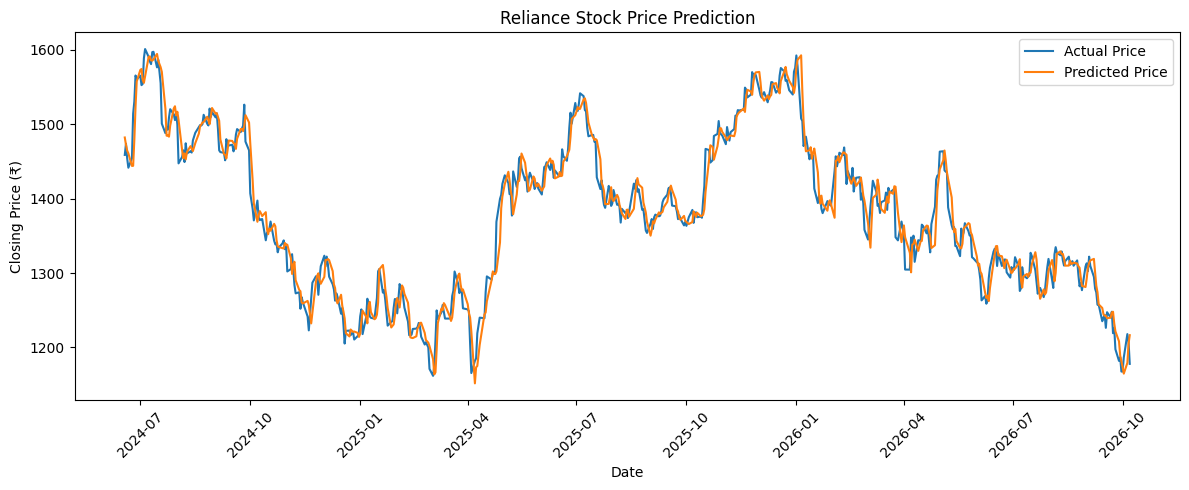

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(data.iloc[splitidx:]["Date"], ytest, label="Actual Price")
plt.plot(data.iloc[splitidx:]["Date"], predictions, label="Predicted Price")
plt.title("Reliance Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations

- Linear Regression led to obtaining an MAE score of ₹15.15 and RMSE score of ₹20.35 on the test data set.
- Linear Regression model failed to produce a better result compared to the naive baseline, which gave MAE value of ₹9.51 and RMSE of ₹14.32.
- Large value of RMSE indicates that some large errors occurred.
- Historical data such as stock values could not add anything in terms of prediction when compared to using just closing price for next day’s prediction.